In [ ]:
import torch
from diffusers.utils import make_image_grid
from IPython.display import display, clear_output
from PIL import Image
from slideredit.pipelines import SliderEditFluxKontextPipeline
from itertools import product

/home/will/work/SliderEdit/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import torch

# Core status check
print(f"Is CUDA available? {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA Device Count: {torch.cuda.device_count()}")
    print(f"Current Device ID: {torch.cuda.current_device()}")
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"PyTorch CUDA Build Version: {torch.version.cuda}")
    print(f"cuDNN Enabled: {torch.backends.cudnn.enabled}")
else:
    print("CUDA is not available. PyTorch is running strictly on your CPU.")


Is CUDA available? True
CUDA Device Count: 1
Current Device ID: 0
Device Name: NVIDIA A10G
PyTorch CUDA Build Version: 12.8
cuDNN Enabled: True


## GSTLoRA

In [ ]:
import gc
import torch
from diffusers import FluxTransformer2DModel, BitsAndBytesConfig

# Free any pipeline from a previous run of this cell so re-running it does not
# stack VRAM (the usual cause of OOM in a long-lived notebook kernel).
for _name in ("pipe", "transformer"):
    if _name in globals():
        del globals()[_name]
gc.collect()
torch.cuda.empty_cache()

MODEL_ID = "black-forest-labs/FLUX.1-Kontext-dev"

# The 12B transformer is ~24GB in bf16 -- too large on its own for a 23GB GPU
# (e.g. A10G). Quantize it to 4-bit NF4 (~7GB) so the full pipeline fits.
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
transformer = FluxTransformer2DModel.from_pretrained(
    MODEL_ID,
    subfolder="transformer",
    quantization_config=quant_config,
    torch_dtype=torch.bfloat16,
)

pipe = SliderEditFluxKontextPipeline.from_pretrained(
    MODEL_ID,
    transformer=transformer,
    torch_dtype=torch.bfloat16,
)
# The 4-bit transformer is already on CUDA. Move the remaining (unquantized)
# components there too -- do NOT call pipe.to("cuda"), as bitsandbytes-quantized
# modules cannot be relocated that way.
pipe.text_encoder.to("cuda")
pipe.text_encoder_2.to("cuda")
pipe.vae.to("cuda")
pipe.enable_vae_tiling()

Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.99it/s]


In [ ]:
# pipe.load_gstlora("./checkpoints/example_training_gstlora_iter500.safetensors")
# clear_output()
# print("Pipeline with GSTLoRA loaded successfully (transformer in 4-bit NF4)!")

In [ ]:
# img = Image.open("./datasets/slideredit_faces_dataset/woman_7.png").convert("RGB")
# edit_prompt = "make the hair of the person curly"
# alpha_values = [1, 0.8, 0.5, 0, -0.5, -1]

# outputs = []
# for alpha in alpha_values:
#     output_image = pipe(
#         image=img,  
#         prompt=edit_prompt,
#         generator=torch.Generator().manual_seed(0),
#         slider_alpha=alpha,
#     ).images[0]
#     outputs.append(output_image)

# clear_output()
# display(img.resize((200, 200)))
# print(f"Edit prompt: {edit_prompt}")
# make_image_grid([x.resize((200, 200)) for x in outputs], rows=1, cols=len(outputs))

## STLoRA

In [ ]:
pipe.load_stlora("./checkpoints/example_training_stlora_iter1200.pt", lora_rank=16, lora_dropout=0.0)
clear_output()
print("Pipeline with STLoRA loaded successfully!")

Pipeline with STLoRA loaded successfully!


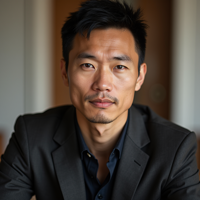

Edit prompt: make the person fat and make the person laugh


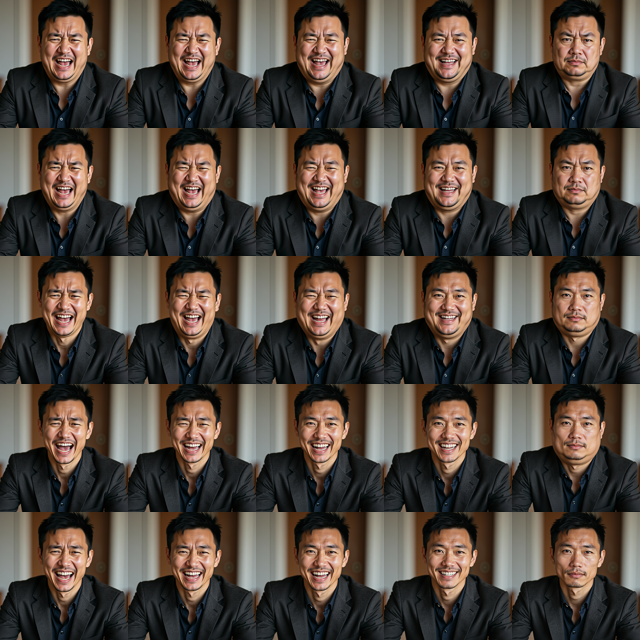

In [ ]:
img = Image.open("/home/will/work/SliderEdit/generalize_results/inputs/2026-06-27 20.21.43.jpg")
edit_prompt = "make the person fat and make the person laugh"
edit_subprompts = ["make the person fat", "make the person laugh"]
alpha_values_list = product([-1, -0.5, 0, 0.5, 1], repeat=2)

outputs = []
for alpha_values in alpha_values_list:
    output_image = pipe(
        image=img,
        prompt=edit_prompt,
        generator=torch.Generator().manual_seed(0),
        subprompts_list=edit_subprompts,
        slider_alpha_list=alpha_values,
    ).images[0]
    outputs.append(output_image)

clear_output()
display(img.resize((200, 200)))
print(f"Edit prompt: {edit_prompt}")
make_image_grid([x.resize((128, 128)) for x in outputs], rows=5, cols=5)